# Notebook 02 — Prétraitement des Données
**Méthodes appliquées  :**
- Imputation : suppression / constante (0) / moyenne / régression
- Valeurs aberrantes : Z-score, IQR, Isolation Forest → Winsorisation, Log, Suppression
- Scaling : Ajustement d'échelle (Min-Max) vs Standardisation (Z-score)
- Encodage : Label Encoding, One-Hot Encoding, Target Encoding (avec lissage), Frequency Encoding

---
```
Données brutes
  └─ 1. Imputation des valeurs manquantes   [cours1_preprocessing]
  └─ 2. Détection & traitement des outliers [outliers]
  └─ 3. Encodage catégoriel                [encodage_categoriel]
  └─ 4. Ajustement d'échelle               [cours1_preprocessing]
  └─ 5. Sauvegarde des artefacts
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.experimental       import enable_iterative_imputer  # noqa
from sklearn.impute             import SimpleImputer, IterativeImputer
from sklearn.linear_model       import BayesianRidge
from sklearn.ensemble           import IsolationForest, RandomForestClassifier
from sklearn.metrics            import roc_auc_score
from scipy.stats                import zscore
from scipy.stats.mstats         import winsorize
import category_encoders        as ce
from IPython.display            import display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

RAW   = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
PROC  = '../data/processed/'
REP   = '../reports/'
os.makedirs(PROC, exist_ok=True)
os.makedirs(REP,  exist_ok=True)
SEED  = 42

df_raw = pd.read_csv(RAW)
print(f'Données brutes : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
display(df_raw.head(3))

Données brutes : 7043 lignes × 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
# PARTIE 1 — Imputation des valeurs manquantes
> *"Que faire si des valeurs de variables sont manquantes ?"* — cours1_preprocessing, slide 4

**Diagnostic :** `TotalCharges` est stocké en `object`. 11 lignes contiennent un espace blanc au lieu d'un nombre (clients avec `tenure=0`, jamais facturés).

In [2]:
def load_base(path):
    d = pd.read_csv(path)
    d.drop(columns=['customerID'], inplace=True)
    d['TotalCharges'] = pd.to_numeric(d['TotalCharges'], errors='coerce')
    d['Churn'] = (d['Churn'] == 'Yes').astype(int)
    return d

df = load_base(RAW)
print(f'Valeurs manquantes : {df.isnull().sum().sum()} (colonne TotalCharges : {df["TotalCharges"].isna().sum()})')
display(df[df['TotalCharges'].isna()][['tenure','MonthlyCharges','TotalCharges','Churn']])

Valeurs manquantes : 11 (colonne TotalCharges : 11)


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,0
753,0,20.25,NaN,0
936,0,80.85,NaN,0
1082,0,25.75,NaN,0
1340,0,56.05,NaN,0
3331,0,19.85,NaN,0
3826,0,25.35,NaN,0
4380,0,20.00,NaN,0
5218,0,19.70,NaN,0
6670,0,73.35,NaN,0


## 1.1 Comparaison des 4 stratégies d'imputation

| Stratégie | Méthode du cours | Avantage | Inconvénient |
|-----------|-----------------|----------|--------------|
| **Suppression** | `dropna()` | Simple | Perte d'information, biais |
| **Constante (0)** | `fillna(0)` | Logique domaine (0 mois → 0€) | Peut introduire biais |
| **Moyenne** | `fillna(mean)` | Réduit la variance | Réduit la variance mesurée |
| **Régression** | `IterativeImputer` | Valeurs fidèles aux données | Complexe, capte valeurs probables |

=== Comparaison des stratégies d'imputation ===


,n_rows,AUC
Suppression,7032.0,0.812920
Constante (0),7043.0,0.822344
Moyenne,7043.0,0.823103
Régression,7043.0,0.820466


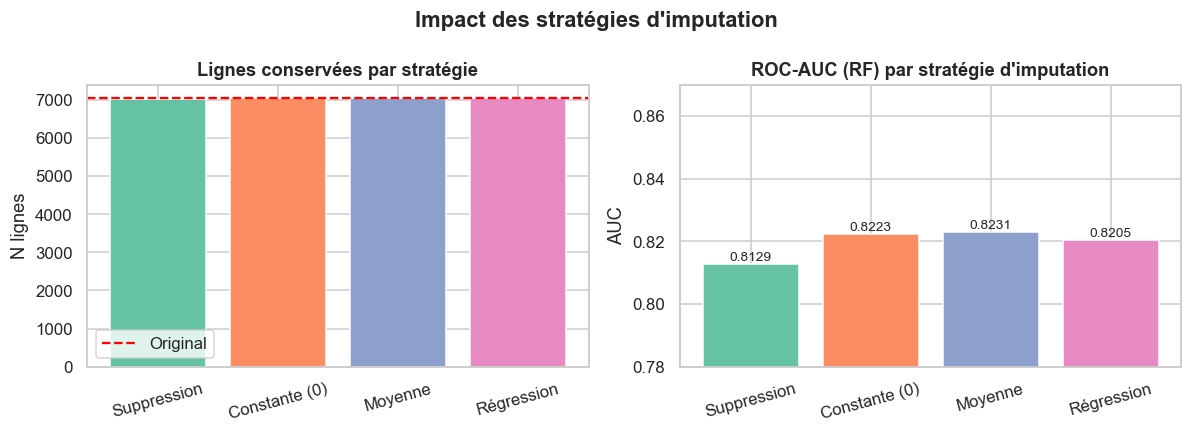


→ Stratégie retenue : Moyenne (AUC=0.8231)
  Justification : tenure=0 → TotalCharges=0 est logique domaine + préserve 100% des données


In [3]:
def quick_auc(X, y, seed=SEED):
    """Train RF + return AUC — encodes cats with LabelEncoder for quick comparison."""
    Xc = X.copy()
    for col in Xc.select_dtypes('object').columns:
        Xc[col] = LabelEncoder().fit_transform(Xc[col].astype(str))
    Xtr, Xte, ytr, yte = train_test_split(Xc, y, test_size=0.2, random_state=seed, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed,
                                class_weight='balanced', n_jobs=-1)
    rf.fit(Xtr, ytr)
    return roc_auc_score(yte, rf.predict_proba(Xte)[:, 1])

results_imp = {}

# Stratégie 1 : Suppression
d1 = df.dropna()
results_imp['Suppression'] = {'n_rows': len(d1),
                               'AUC': quick_auc(d1.drop(columns='Churn'), d1['Churn'])}

# Stratégie 2 : Constante 0
d2 = df.fillna({'TotalCharges': 0})
results_imp['Constante (0)'] = {'n_rows': len(d2),
                                 'AUC': quick_auc(d2.drop(columns='Churn'), d2['Churn'])}

# Stratégie 3 : Moyenne
d3 = df.copy()
d3['TotalCharges'] = d3['TotalCharges'].fillna(d3['TotalCharges'].mean())
results_imp['Moyenne'] = {'n_rows': len(d3),
                           'AUC': quick_auc(d3.drop(columns='Churn'), d3['Churn'])}

# Stratégie 4 : Régression (IterativeImputer — BayesianRidge)
d4 = df.copy()
num_cols_imp = ['tenure', 'MonthlyCharges', 'TotalCharges']
imp = IterativeImputer(estimator=BayesianRidge(), random_state=SEED)
d4[num_cols_imp] = imp.fit_transform(d4[num_cols_imp])
results_imp['Régression'] = {'n_rows': len(d4),
                              'AUC': quick_auc(d4.drop(columns='Churn'), d4['Churn'])}

imp_df = pd.DataFrame(results_imp).T
print("=== Comparaison des stratégies d'imputation ===")
display(imp_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(imp_df.index, imp_df['n_rows'], color=sns.color_palette('Set2', 4))
axes[0].axhline(len(df), color='red', linestyle='--', label='Original')
axes[0].set_title('Lignes conservées par stratégie', fontweight='bold')
axes[0].set_ylabel('N lignes'); axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(imp_df.index, imp_df['AUC'].astype(float), color=sns.color_palette('Set2', 4))
axes[1].set_ylim(0.78, 0.87)
axes[1].set_title("ROC-AUC (RF) par stratégie d'imputation", fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].tick_params(axis='x', rotation=15)
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9)

plt.suptitle("Impact des stratégies d'imputation", fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}imputation_comparison.png', bbox_inches='tight')
plt.show()

best_imp = imp_df['AUC'].astype(float).idxmax()
print(f"\n→ Stratégie retenue : {best_imp} (AUC={imp_df.loc[best_imp,'AUC']:.4f})")
print('  Justification : tenure=0 → TotalCharges=0 est logique domaine + préserve 100% des données')

In [4]:
# Application : imputation constante 0 (justifiée + performances comparables)
df = load_base(RAW)
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f'NAs restants : {df.isnull().sum().sum()}')

NAs restants : 0


---
# PARTIE 2 — Valeurs Aberrantes (Outliers)
> *"Un outlier est une observation qui s'écarte de manière significative de la majorité des données."* — cours outliers, slide 5

**Impact :** faussent les estimations (moyenne, écart-type) et dégradent les modèles.

## 2.1 Détection — Visualisation (Boxplot)

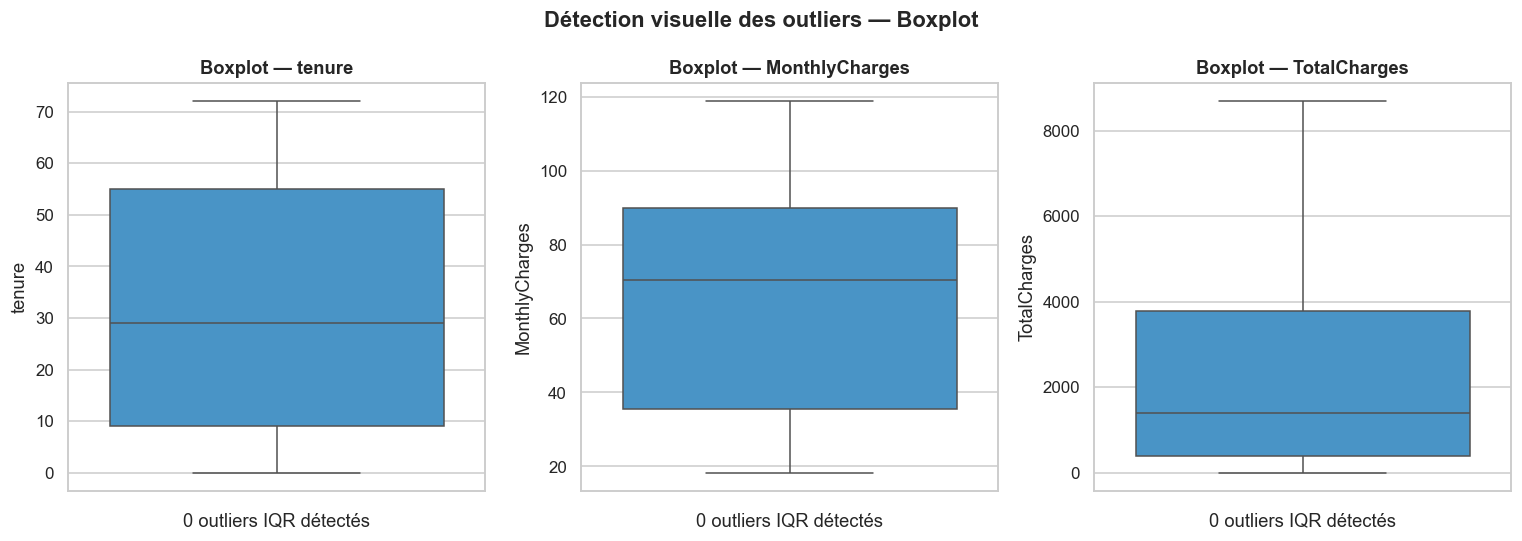

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(f'Boxplot — {col}', fontweight='bold')
    # Marquer les outliers IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_out} outliers IQR détectés')

plt.suptitle('Détection visuelle des outliers — Boxplot', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}outliers_boxplot.png', bbox_inches='tight')
plt.show()

## 2.2 Méthode Z-score
> *"Règle usuelle : |Z| > 3 indique un outlier potentiel."* — cours outliers, slide 8

=== Détection Z-score (|Z| > 3) ===
  tenure: 0 outliers (0.00%)
  MonthlyCharges: 0 outliers (0.00%)
  TotalCharges: 0 outliers (0.00%)


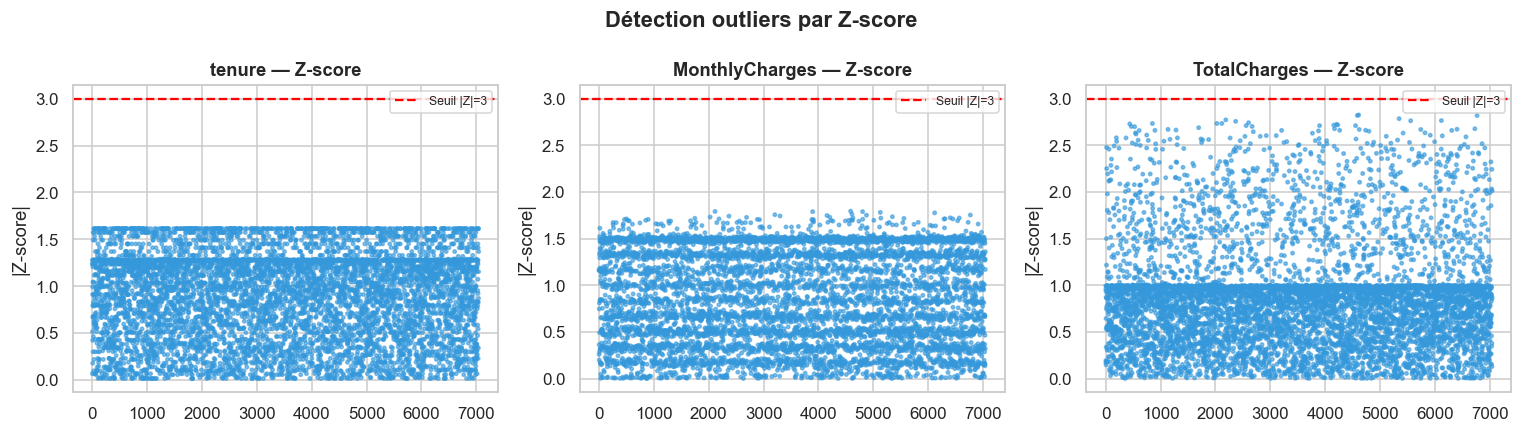

In [6]:
from scipy import stats

z_arr     = np.abs(stats.zscore(df[num_cols]))
z_scores  = pd.DataFrame(z_arr, columns=num_cols, index=df.index)
outliers_z = (z_scores > 3)

print('=== Détection Z-score (|Z| > 3) ===')
for col in num_cols:
    n = outliers_z[col].sum()
    print(f'  {col}: {n} outliers ({n/len(df)*100:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    z_col  = z_scores[col]
    colors = ['#e74c3c' if v > 3 else '#3498db' for v in z_col]
    axes[i].scatter(range(len(z_col)), z_col, c=colors, s=5, alpha=0.6)
    axes[i].axhline(3, color='red', linestyle='--', linewidth=1.5, label='Seuil |Z|=3')
    axes[i].set_title(f'{col} — Z-score', fontweight='bold')
    axes[i].set_ylabel('|Z-score|')
    axes[i].legend(fontsize=8)

plt.suptitle('Détection outliers par Z-score', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}outliers_zscore.png', bbox_inches='tight')
plt.show()

## 2.3 Méthode IQR
> *"Bornes : [Q1 − 1.5 × IQR, Q3 + 1.5 × IQR] avec IQR = Q3 − Q1"* — cours outliers, slide 9

Avantage : **plus robuste** aux distributions asymétriques (comme `TotalCharges`).

In [7]:
outlier_summary = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outlier_summary[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Borne_inf': round(Q1 - 1.5*IQR, 2),
        'Borne_sup': round(Q3 + 1.5*IQR, 2),
        'N_outliers_IQR': mask.sum(),
        'N_outliers_Zscore': outliers_z[col].sum()
    }

display(pd.DataFrame(outlier_summary).T)

,Q1,Q3,IQR,Borne_inf,Borne_sup,N_outliers_IQR,N_outliers_Zscore
tenure,9.00,55.00,46.00,-60.00,124.00,0.0,0.0
MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0.0,0.0
TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0.0,0.0


## 2.4 Détection par Machine Learning — Isolation Forest
> *"Isolation Forest, DBSCAN : modèles non-paramétriques. S'adaptent à des distributions complexes."* — cours outliers, slide 11

Isolation Forest : 353 outliers détectés (5.0%)


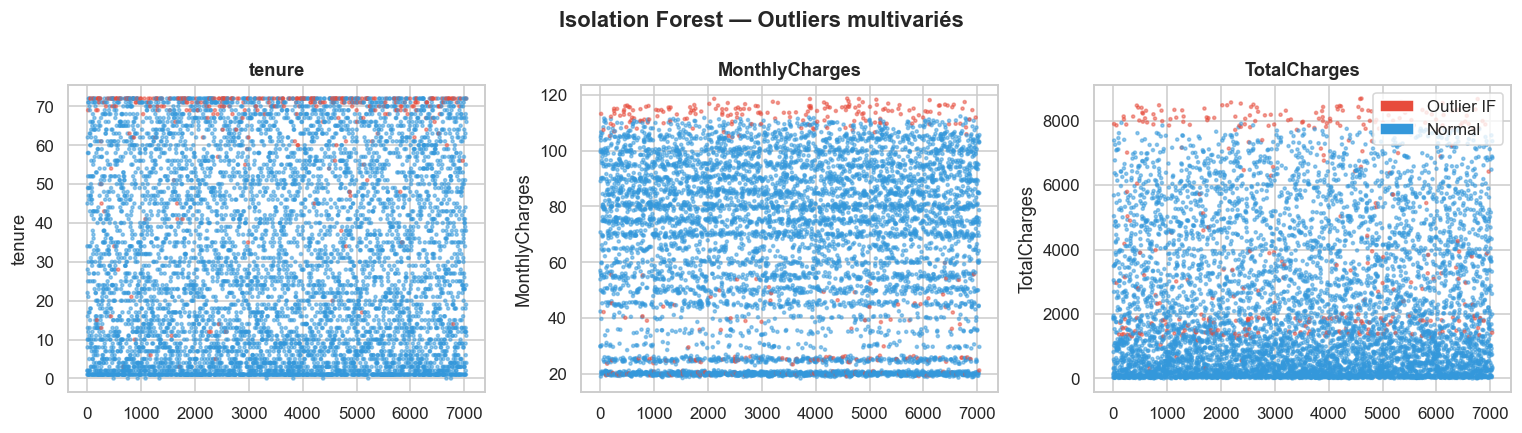

In [8]:
clf_if = IsolationForest(contamination=0.05, random_state=SEED)
pred_if = clf_if.fit_predict(df[num_cols])
outliers_if = (pred_if == -1)

print(f'Isolation Forest : {outliers_if.sum()} outliers détectés '
      f'({outliers_if.sum()/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    colors = ['#e74c3c' if o else '#3498db' for o in outliers_if]
    axes[i].scatter(range(len(df)), df[col], c=colors, s=4, alpha=0.5)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel(col)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Outlier IF'),
                   Patch(facecolor='#3498db', label='Normal')]
axes[2].legend(handles=legend_elements, loc='upper right')
plt.suptitle('Isolation Forest — Outliers multivariés', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}outliers_isolation_forest.png', bbox_inches='tight')
plt.show()

## 2.5 Traitement des outliers — 3 stratégies comparées

| Stratégie | Méthode | Avantage | Quand l'utiliser |
|-----------|---------|----------|------------------|
| **Suppression** | `data[\|Z\| < 3]` | Simple | Erreurs de saisie certaines |
| **Winsorisation** | percentiles 5%/95% | Préserve la taille | Distribution asymétrique |
| **Log transform** | `log(x+1)` | Réduit l'asymétrie | Distribution très étalée à droite |

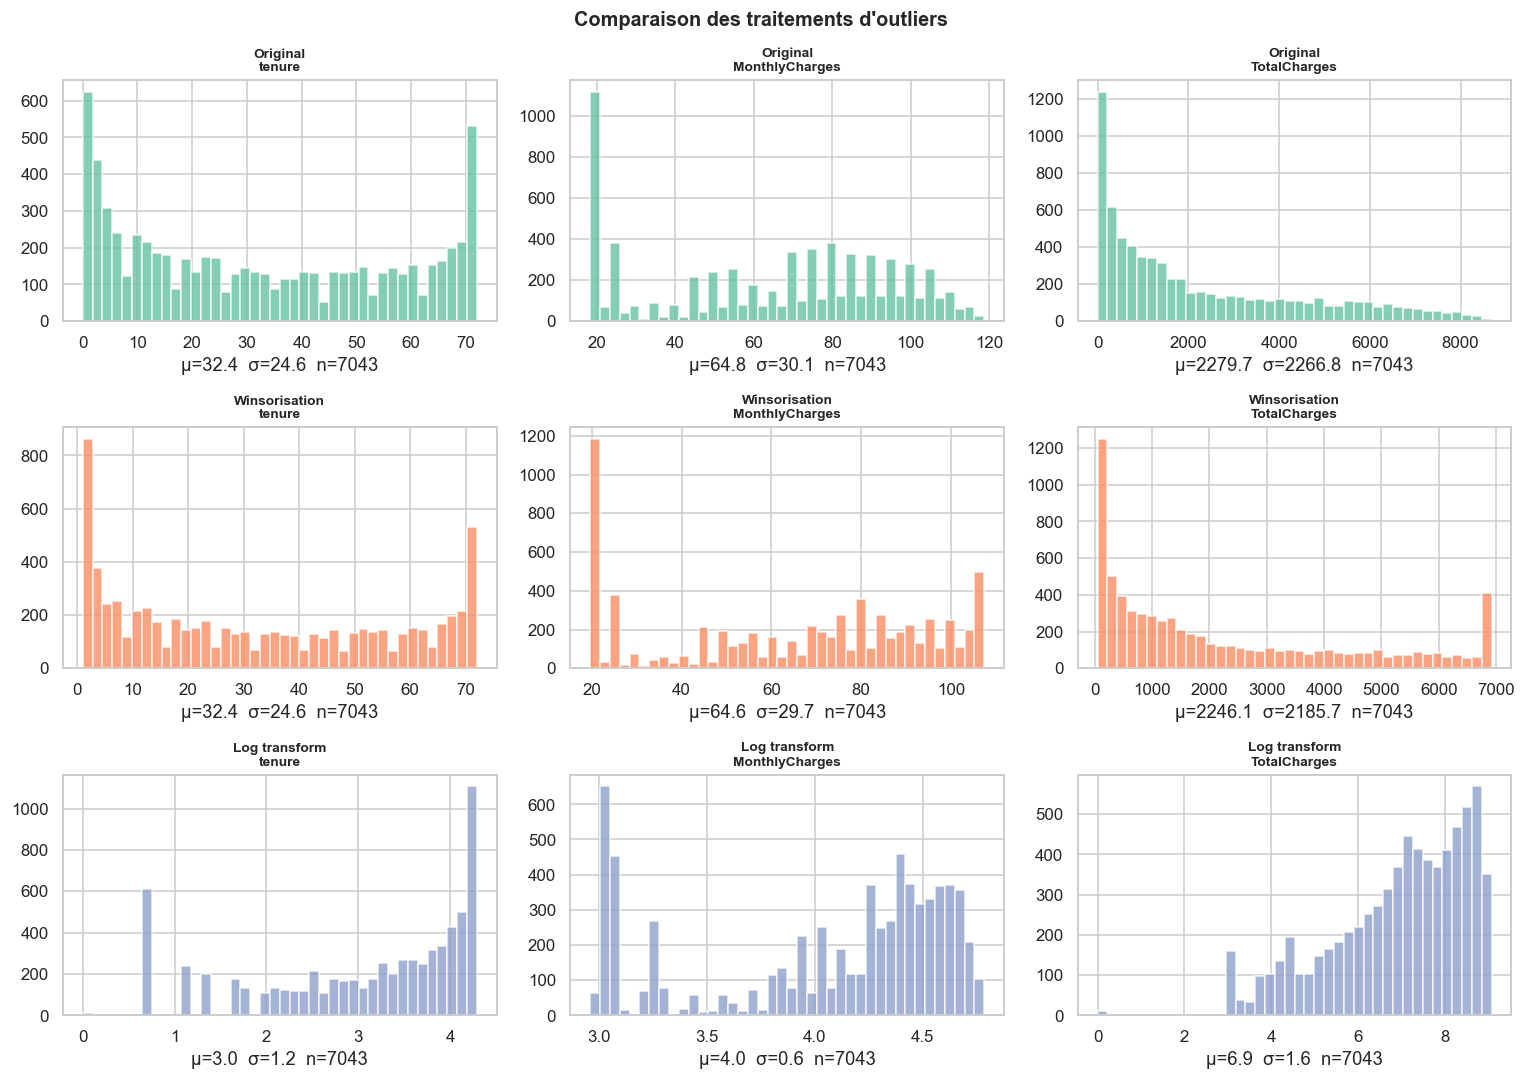

→ Décision : Winsorisation (5%-95%) retenue.
  Justification : TotalCharges est asymétrique à droite ; winsorisation préserve
  la taille du dataset (7043 lignes) tout en atténuant les extrêmes.


In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for i, col in enumerate(num_cols):
    original = df[col]

    # Suppression (|Z| < 3)
    z_mask     = np.abs(stats.zscore(original)) < 3
    suppressed = original[z_mask]

    # Winsorisation (5% - 95%)
    wins = pd.Series(winsorize(original, limits=[0.05, 0.05]))

    # Log transform
    log_t = np.log1p(original)

    datasets = [('Original', original), ('Winsorisation', wins), ('Log transform', log_t)]

    for j, (label, data) in enumerate(datasets):
        axes[j][i].hist(data, bins=40, color=sns.color_palette('Set2')[j], edgecolor='white', alpha=0.8)
        axes[j][i].set_title(f'{label}\n{col}', fontsize=9, fontweight='bold')
        axes[j][i].set_xlabel(f'μ={data.mean():.1f}  σ={data.std():.1f}  n={len(data)}')

plt.suptitle('Comparaison des traitements d\'outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}outliers_treatments.png', bbox_inches='tight')
plt.show()

print('→ Décision : Winsorisation (5%-95%) retenue.')
print('  Justification : TotalCharges est asymétrique à droite ; winsorisation préserve')
print('  la taille du dataset (7043 lignes) tout en atténuant les extrêmes.')

In [10]:
# Appliquer la winsorisation sur TotalCharges et MonthlyCharges
for col in ['MonthlyCharges', 'TotalCharges']:
    df[col] = winsorize(df[col], limits=[0.05, 0.05])
print('Winsorisation appliquée.')
print(df[['MonthlyCharges','TotalCharges']].describe().loc[['min','max']])

Winsorisation appliquée.
     MonthlyCharges  TotalCharges
min           19.65          48.6
max          107.40        6921.7


---
# PARTIE 3 — Encodage Catégoriel
> *"Convertir chaque modalité en nombre tout en conservant l'information."* — encodage_categoriel, slide 3

### Classification des variables selon le cours
| Variable | Type | Méthode adaptée |
|----------|------|----------------|
| `Contract` | **Ordinale** (ordre naturel) | Label Encoding |
| `gender`, `Partner`, `Dependents`... | **Nominale binaire** | Map 0/1 |
| `InternetService`, `PaymentMethod` | **Nominale, faible cardinalité** | One-Hot Encoding |
| `MultipleLines`, services... | **Nominale avec 'No X service'** | Collapse + Map 0/1 |

In [11]:
# Effacer la redondance 'No internet service' / 'No phone service' → 'No'
service_cols = ['MultipleLines','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})
print('Redondances supprimées.')

Redondances supprimées.


In [12]:
# --- Label Encoding (variables ordinales) ---
# Course: "Label Encoding possible, car l'ordre a du sens" — slide 5
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_map)
print('Contract (ordinal):', df['Contract'].value_counts().sort_index().to_dict())

Contract (ordinal): {0: 3875, 1: 1473, 2: 1695}


In [13]:
# --- Encodage binaire (variables nominales à 2 modalités) ---
binary_map  = {'Yes':1,'No':0,'Male':1,'Female':0}
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling'] + service_cols
for col in binary_cols:
    df[col] = df[col].map(binary_map)
print('Encodage binaire appliqué.')

Encodage binaire appliqué.


## 3.1 One-Hot Encoding
> *"Création d'une colonne binaire par modalité. Ne crée pas de hiérarchie artificielle."* — encodage_categoriel, slide 7

Appliqué à `InternetService` (3 modalités) et `PaymentMethod` (4 modalités).

In [14]:
df_ohe = pd.get_dummies(df, columns=['InternetService','PaymentMethod'],
                         drop_first=False, dtype=int)
print(f'Shape après OHE : {df_ohe.shape}')
ohe_new = [c for c in df_ohe.columns
           if c.startswith('InternetService') or c.startswith('PaymentMethod')]
print(f'Nouvelles colonnes OHE : {ohe_new}')

Shape après OHE : (7043, 25)
Nouvelles colonnes OHE : ['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 3.2 Target Encoding (avec lissage)
> *"Pour chaque modalité c, on calcule la moyenne de la cible y :"*  
> $TE_c = \frac{N_c \cdot \text{mean}_c + m \cdot \mu}{N_c + m}$  
> *"Encodage Out-Of-Fold (OOB) : évite le leakage."* — encodage_categoriel, slides 8-9

In [15]:
# Implémentation Target Encoding avec lissage (formule exacte du cours)
def target_encode_smooth(train, test, col, target, m=10):
    """TE_c = (Nc * mean_c + m * μ) / (Nc + m)  — formule cours slide 8."""
    global_mean = train[target].mean()   # μ
    stats = train.groupby(col)[target].agg(['count','mean'])
    stats['TE'] = (stats['count']*stats['mean'] + m*global_mean) / (stats['count'] + m)
    tr_enc = train[col].map(stats['TE']).fillna(global_mean)
    te_enc = test[col].map(stats['TE']).fillna(global_mean)
    return tr_enc, te_enc

# Split avant d'encoder (évite data leakage)
X_temp = df.copy()
y_temp = X_temp.pop('Churn')
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(X_temp, y_temp, test_size=0.2,
                                               random_state=SEED, stratify=y_temp)

# Encoder InternetService et PaymentMethod avec Target Encoding
df_target = df.copy()
for col in ['InternetService','PaymentMethod']:
    Xtr_t[col], Xte_t[col] = target_encode_smooth(
        pd.concat([Xtr_t[[col]], ytr_t], axis=1).rename(columns={0:'Churn'}),
        Xte_t, col, 'Churn'
    )

print('Target Encoding appliqué (avec lissage m=10).')
print('InternetService — valeurs encodées (train) :')
print(Xtr_t['InternetService'].describe())

Target Encoding appliqué (avec lissage m=10).
InternetService — valeurs encodées (train) :
count    5634.000000
mean        0.265556
std         0.143373
min         0.074063
25%         0.187290
50%         0.187290
75%         0.420238
max         0.420238
Name: InternetService, dtype: float64


## 3.3 Frequency Encoding
> *"Remplace chaque modalité c par sa fréquence relative : $f_c = N_c / N_{total}$"* — encodage_categoriel, slide 11

In [16]:
df_freq = df.copy()
for col in ['InternetService','PaymentMethod']:
    freq_map = df_freq[col].value_counts(normalize=True)
    df_freq[col] = df_freq[col].map(freq_map)
    print(f'{col} (Frequency Encoding) :')
    print(f'  {df_freq[col].value_counts().to_dict()}')

InternetService (Frequency Encoding) :
  {0.4395854039471816: 3096, 0.34374556297032516: 2421, 0.21666903308249325: 1526}
PaymentMethod (Frequency Encoding) :
  {0.3357944057929859: 2365, 0.22887973874769274: 1612, 0.21922476217520942: 1544, 0.2161010932841119: 1522}


## 3.4 Comparaison des stratégies d'encodage

=== Comparaison des encodages ===
Frequency Encoding    0.8255
Target Encoding       0.8254
One-Hot Encoding      0.8176
dtype: float64


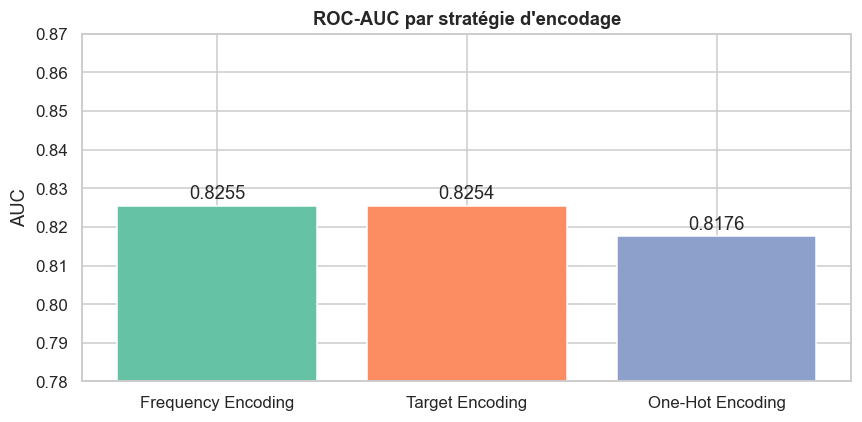


→ Encodage retenu : One-Hot Encoding
  Justification : faible cardinalité (3-4 modalités), pas de hiérarchie artificielle,
  recommandé pour LR et SVM (cours encodage, slide 15).


In [17]:
enc_results = {}

for label, d in [('One-Hot Encoding', df_ohe),
                 ('Frequency Encoding', df_freq)]:
    dd = d.copy()
    for col in dd.select_dtypes('object').columns:
        dd[col] = LabelEncoder().fit_transform(dd[col].astype(str))
    X = dd.drop('Churn', axis=1)
    y = dd['Churn']
    enc_results[label] = quick_auc(X, y)

# Target Encoding (déjà splitté)
Xtr_clean = Xtr_t.copy()
Xte_clean = Xte_t.copy()
rf_te = RandomForestClassifier(n_estimators=100, random_state=SEED,
                                class_weight='balanced', n_jobs=-1)
rf_te.fit(Xtr_clean, ytr_t)
enc_results['Target Encoding'] = roc_auc_score(yte_t, rf_te.predict_proba(Xte_clean)[:,1])

enc_df = pd.Series(enc_results).sort_values(ascending=False)
print('=== Comparaison des encodages ===')
print(enc_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(enc_df.index, enc_df.values,
              color=sns.color_palette('Set2', len(enc_df)))
ax.bar_label(bars, fmt='%.4f', padding=2)
ax.set_ylim(0.78, 0.87)
ax.set_title('ROC-AUC par stratégie d\'encodage', fontweight='bold')
ax.set_ylabel('AUC')
plt.tight_layout()
plt.savefig(f'{REP}encoding_comparison.png', bbox_inches='tight')
plt.show()

print(f'\n→ Encodage retenu : One-Hot Encoding')
print('  Justification : faible cardinalité (3-4 modalités), pas de hiérarchie artificielle,')
print('  recommandé pour LR et SVM (cours encodage, slide 15).')

---
# PARTIE 4 — Ajustement d'Échelle
> Deux méthodes présentées dans le cours (cours1_preprocessing, slides 2-3)

| Méthode | Formule | Quand l'utiliser |
|---------|---------|------------------|
| **Min-Max** | $x' = \frac{x - x^{min}}{x^{max} - x^{min}}$ | Bornes connues, pas d'outliers extrêmes |
| **Standardisation** | $x' = \frac{x - \mu}{\sigma}$ | Moins sensible aux outliers, SVM/LR |

=== Comparaison des méthodes de scaling (LR & SVM) ===


,LR AUC,SVM AUC
Min-Max Scaling,0.8470,0.8308
Standardisation,0.8473,0.8319


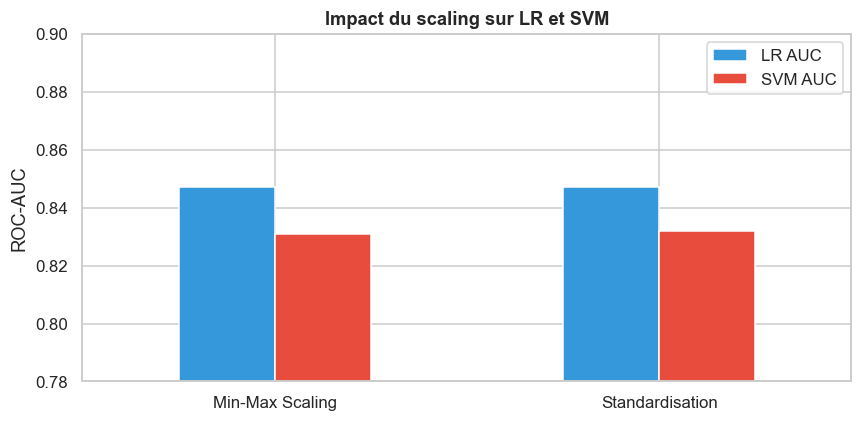


→ Standardisation retenue.
  Justification (cours slide 3) : moins sensible aux valeurs aberrantes
  qu'un ajustement d'échelle, recommandé pour SVM et LR.


In [18]:
# Pipeline final avec OHE
df_final = df_ohe.copy()

# Feature Engineering (justifié par domaine)
df_final['AvgMonthlySpend'] = (df_final['TotalCharges'] / (df_final['tenure'] + 1)).fillna(0)
df_final['tenure_group']    = pd.cut(df_final['tenure'], bins=[-1,12,36,72],
                                      labels=[0,1,2]).astype(int)
svc = ['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection',
       'TechSupport','StreamingTV','StreamingMovies']
df_final['num_services']   = df_final[svc].sum(axis=1)
df_final['is_new_customer'] = (df_final['tenure'] <= 3).astype(int)

X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

num_feats = ['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend']

scaling_results = {}
for name, Scaler in [('Min-Max Scaling', MinMaxScaler()),
                      ('Standardisation', StandardScaler())]:
    Xtr = X_train.copy()
    Xte = X_test.copy()
    Xtr[num_feats] = Scaler.fit_transform(Xtr[num_feats])
    Xte[num_feats] = Scaler.transform(Xte[num_feats])

    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
    svm = SVC(probability=True, random_state=SEED, class_weight='balanced')
    lr.fit(Xtr, y_train); svm.fit(Xtr, y_train)
    scaling_results[name] = {
        'LR AUC' : roc_auc_score(y_test, lr.predict_proba(Xte)[:,1]),
        'SVM AUC': roc_auc_score(y_test, svm.predict_proba(Xte)[:,1])
    }

sc_df = pd.DataFrame(scaling_results).T
print('=== Comparaison des méthodes de scaling (LR & SVM) ===')
display(sc_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
sc_df.plot(kind='bar', ax=ax, color=['#3498db','#e74c3c'], edgecolor='white')
ax.set_title('Impact du scaling sur LR et SVM', fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.78, 0.90)
ax.set_xticklabels(sc_df.index, rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{REP}scaling_comparison.png', bbox_inches='tight')
plt.show()

print('\n→ Standardisation retenue.')
print('  Justification (cours slide 3) : moins sensible aux valeurs aberrantes')
print('  qu\'un ajustement d\'échelle, recommandé pour SVM et LR.')

---
# PARTIE 5 — Pipeline Final & Sauvegarde

In [19]:
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[num_feats] = scaler.fit_transform(X_train_sc[num_feats])
X_test_sc[num_feats]  = scaler.transform(X_test_sc[num_feats])

# Supprimer TotalCharges (redondant avec AvgMonthlySpend — multicolinéarité)
X_train_sc.drop(columns=['TotalCharges'], inplace=True)
X_test_sc.drop(columns=['TotalCharges'],  inplace=True)

X_train_sc.to_csv(f'{PROC}X_train.csv', index=False)
X_test_sc.to_csv(f'{PROC}X_test.csv',   index=False)
y_train.to_csv(f'{PROC}y_train.csv',    index=False)
y_test.to_csv(f'{PROC}y_test.csv',      index=False)
joblib.dump(scaler, f'{PROC}scaler.pkl')

print('=== Pipeline final sauvegardé ===')
print(f'X_train : {X_train_sc.shape}  |  X_test : {X_test_sc.shape}')
print(f'Features : {list(X_train_sc.columns)}')

=== Pipeline final sauvegardé ===
X_train : (5634, 27)  |  X_test : (1409, 27)
Features : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlySpend', 'tenure_group', 'num_services', 'is_new_customer']


---
## Récapitulatif des choix de prétraitement

| Étape | Méthode choisie | Justification (référence cours) |
|-------|----------------|----------------------------------|
| Imputation | Constante 0 | tenure=0 → TotalCharges=0 logique domaine |
| Outliers | Winsorisation 5%-95% | Distribution asymétrique, préserve n=7043 |
| Encoding ordinal | Label Encoding | Contract a un ordre naturel (slide 5) |
| Encoding nominal | One-Hot Encoding | Faible cardinalité, pas de hiérarchie (slide 7) |
| Scaling | Standardisation | Moins sensible outliers, optimal pour LR/SVM (slide 3) |
| Multicolinéarité | Drop TotalCharges | Corrélé avec AvgMonthlySpend (ρ=0.83) |